In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import seaborn as sns
import itertools
from prophet.diagnostics import cross_validation, performance_metrics

In [2]:
df = pd.read_parquet('../data/processed/preprocessed_prophet.parquet')
df.dropna(inplace = True)
df.head()

,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_fastestFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,recommended_fee_minimumFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-05 02:00:00,2.131827e+06,997874.250000,1030.000000,2.077770e+06,1.300139,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:15:00,1.801526e+06,997925.916667,2627.000000,3.407913e+06,2.473960,3.000000,2.666667,2.666667,2.666667,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:30:00,2.055350e+06,997965.916667,922.000000,1.855358e+06,1.355898,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:45:00,2.006800e+06,997970.083333,1296.666667,2.167251e+06,1.536092,2.333333,2.333333,2.333333,2.333333,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 03:00:00,1.773658e+06,997960.333333,2725.333333,3.462741e+06,2.467659,3.333333,3.000000,3.000000,3.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
y = df["recommended_fee_fastestFee"]
X = df.drop(columns = "recommended_fee_fastestFee")

# shift
shift_steps = 96 # shift 24h
X = X.shift(periods=shift_steps)
X.dropna(inplace=True)
y = y.loc[X.index]

# last 24h as test
split_index = len(X) - 96
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


X = X.reset_index()
X = X.drop(columns = "timestamp")

In [4]:
df_prophet = y_train.reset_index()
df_prophet = df_prophet.rename(columns={
    'timestamp': 'ds',
    'recommended_fee_fastestFee': 'y'
})
df_prophet['y'] = np.log1p(df_prophet['y'])
df_prophet.head()

,ds,y
0,2025-03-06 02:00:00,1.299283
1,2025-03-06 02:15:00,1.299283
2,2025-03-06 02:30:00,1.386294
3,2025-03-06 02:45:00,1.299283
4,2025-03-06 03:00:00,1.203973


In [ ]:
# model = Prophet(
#     daily_seasonality=False,
#     weekly_seasonality=False
# )
# # model = Prophet(
# #     daily_seasonality=False,
# #     weekly_seasonality=False,
# #     changepoint_prior_scale = 0.1,
# #     seasonality_prior_scale=20.0,
# #     seasonality_mode='additive',
# #     changepoint_range=0.8,
# #     n_changepoints=25
# # )
# model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
# model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
# model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [5]:
X_col = X_train.reset_index()
X_col = X_col.drop(columns = "timestamp")
for i in X_col.columns.values:
    df_prophet[i] = X_col[i].copy()
    # model.add_regressor(i)
df_prophet.dropna(inplace=True)

In [6]:
df_prophet.head()

,ds,y,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
0,2025-03-06 02:00:00,1.299283,2.131827e+06,997874.250000,1030.000000,2.077770e+06,1.300139,2.000000,2.000000,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-03-06 02:15:00,1.299283,1.801526e+06,997925.916667,2627.000000,3.407913e+06,2.473960,2.666667,2.666667,2.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-03-06 02:30:00,1.386294,2.055350e+06,997965.916667,922.000000,1.855358e+06,1.355898,2.000000,2.000000,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-03-06 02:45:00,1.299283,2.006800e+06,997970.083333,1296.666667,2.167251e+06,1.536092,2.333333,2.333333,2.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-03-06 03:00:00,1.203973,1.773658e+06,997960.333333,2725.333333,3.462741e+06,2.467659,3.000000,3.000000,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.3, 0.5],
    'seasonality_prior_scale': [5.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9, 0.95],
    'n_changepoints': [25, 50, 100]
}

In [8]:
# 创建参数组合
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []  # 存放每组评估结果

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        **params
    )
    m.add_seasonality(name='hourly', period=1/24, fourier_order=6)
    m.add_seasonality(name='daily', period=1, fourier_order=8)
    m.add_seasonality(name='weekly', period=7, fourier_order=4)

    X_col = X_train.reset_index()
    X_col = X_col.drop(columns = "timestamp")
    for i in X_col.columns.values:
        m.add_regressor(i)
    
    m.fit(df_prophet)
    df_cv = cross_validation(m, initial='7 days', period='1 day', horizon='1 day', parallel="processes")
    df_p = performance_metrics(df_cv)
    
    results.append((params, df_p['rmse'].mean()))
print("Done")

14:23:35 - cmdstanpy - INFO - Chain [1] start processing
14:23:35 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [1] start processing
14:23:37 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [1] done processing
14:23:37 - cmdstanpy - INFO - Chain [

Done


16:28:48 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
best_params = sorted(results, key=lambda x: x[1])[0]
print(f"最优参数组合：{best_params[0]}\n对应RMSE：{best_params[1]:.4f}")

最优参数组合：{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'changepoint_range': 0.95, 'n_changepoints': 25}
对应RMSE：0.6119


In [10]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    changepoint_prior_scale = 0.01,
    seasonality_prior_scale=5.0,
    seasonality_mode='additive',
    changepoint_range=0.95,
    n_changepoints=25
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='daily', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='weekly', period=24, fourier_order=5)  # 每日周期

In [11]:

model.fit(df_prophet)

16:54:28 - cmdstanpy - INFO - Chain [1] start processing
16:54:28 - cmdstanpy - INFO - Chain [1] done processing


### Predict

In [12]:
future = model.make_future_dataframe(periods=96, freq='15min')

for i in X.columns.values:
    future[i] = list(df_prophet[i]) + list(X_test[i])
future.tail()

,ds,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,recommended_fee_minimumFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
3867,2025-04-15 08:45:00,1.633151e+06,997975.750000,3276.000000,1.396672e+07,4.157890,4.000000,3.000000,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,85531.000000,0.0,0.0,0.0
3868,2025-04-15 09:00:00,1.678064e+06,997949.083333,3500.666667,9.019997e+06,3.057228,3.666667,3.333333,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,35681.000000,0.0,0.0,0.0
3869,2025-04-15 09:15:00,1.537996e+06,997967.333333,3057.666667,4.112503e+06,1.797701,2.333333,2.333333,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3870,2025-04-15 09:30:00,1.462210e+06,997982.750000,2109.666667,6.307552e+06,2.342194,2.666667,2.666667,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,17459.666667,0.0,0.0,0.0
3871,2025-04-15 09:45:00,1.145838e+06,997967.750000,860.666667,5.008724e+06,2.913055,3.000000,3.000000,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [13]:
forecast = model.predict(future)

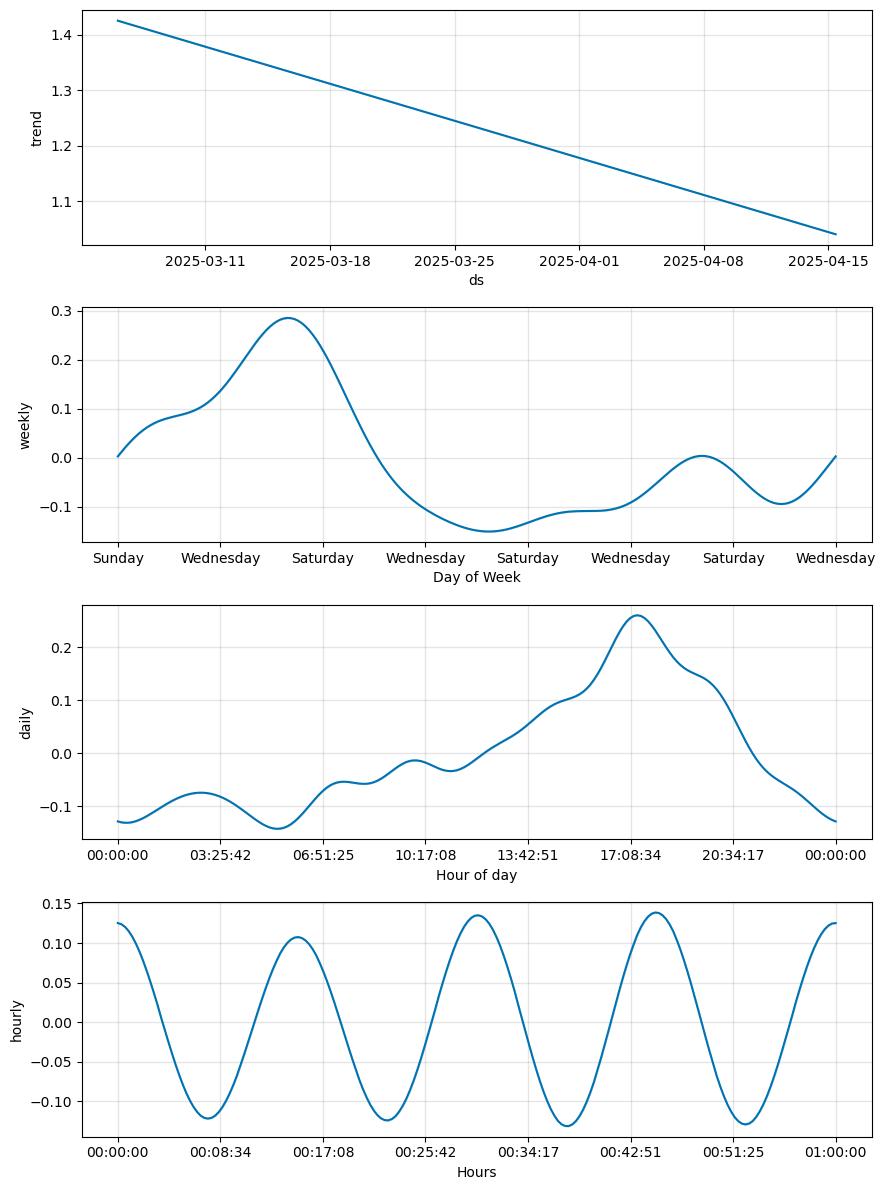

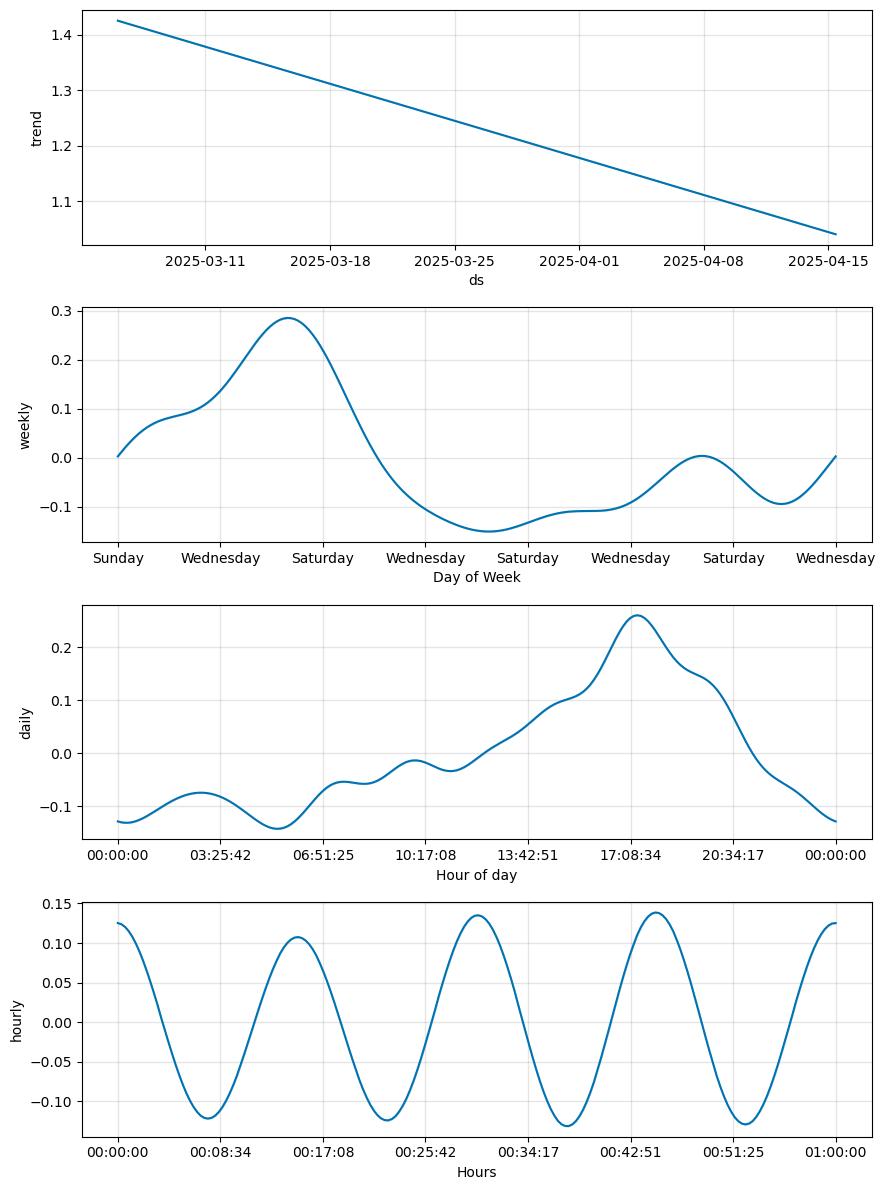

In [14]:
model.plot_components(forecast)

In [15]:
forecast.index = y.index
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,hourly,hourly_lower,hourly_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-06 02:00:00,2025-03-06 02:00:00,1.425838,0.953272,1.767073,1.425838,1.425838,-0.056251,-0.056251,-0.056251,-0.084503,...,0.125257,0.125257,0.125257,-0.097005,-0.097005,-0.097005,0.0,0.0,0.0,1.369587
2025-03-06 02:15:00,2025-03-06 02:15:00,1.425738,0.970317,1.771336,1.425738,1.425738,-0.068932,-0.068932,-0.068932,-0.079051,...,0.107579,0.107579,0.107579,-0.097460,-0.097460,-0.097460,0.0,0.0,0.0,1.356806
2025-03-06 02:30:00,2025-03-06 02:30:00,1.425639,0.972020,1.796602,1.425639,1.425639,-0.038299,-0.038299,-0.038299,-0.075545,...,0.135159,0.135159,0.135159,-0.097913,-0.097913,-0.097913,0.0,0.0,0.0,1.387340
2025-03-06 02:45:00,2025-03-06 02:45:00,1.425539,0.947970,1.752476,1.425539,1.425539,-0.033887,-0.033887,-0.033887,-0.074177,...,0.138653,0.138653,0.138653,-0.098363,-0.098363,-0.098363,0.0,0.0,0.0,1.391652
2025-03-06 03:00:00,2025-03-06 03:00:00,1.425440,0.953478,1.760622,1.425440,1.425440,-0.048606,-0.048606,-0.048606,-0.075053,...,0.125257,0.125257,0.125257,-0.098810,-0.098810,-0.098810,0.0,0.0,0.0,1.376834


In [16]:
y_pred = forecast.iloc[-96:]
# y_pred = y_pred["yhat"]
y_pred = np.expm1(y_pred["yhat"])
y_pred.head()

timestamp
2025-04-14 10:00:00    2.445712
2025-04-14 10:15:00    2.374722
2025-04-14 10:30:00    2.448689
2025-04-14 10:45:00    2.439570
2025-04-14 11:00:00    2.380718
Name: yhat, dtype: float64

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

MAE: 1.0110
RMSE: 1.2495
MAPE: 0.4974


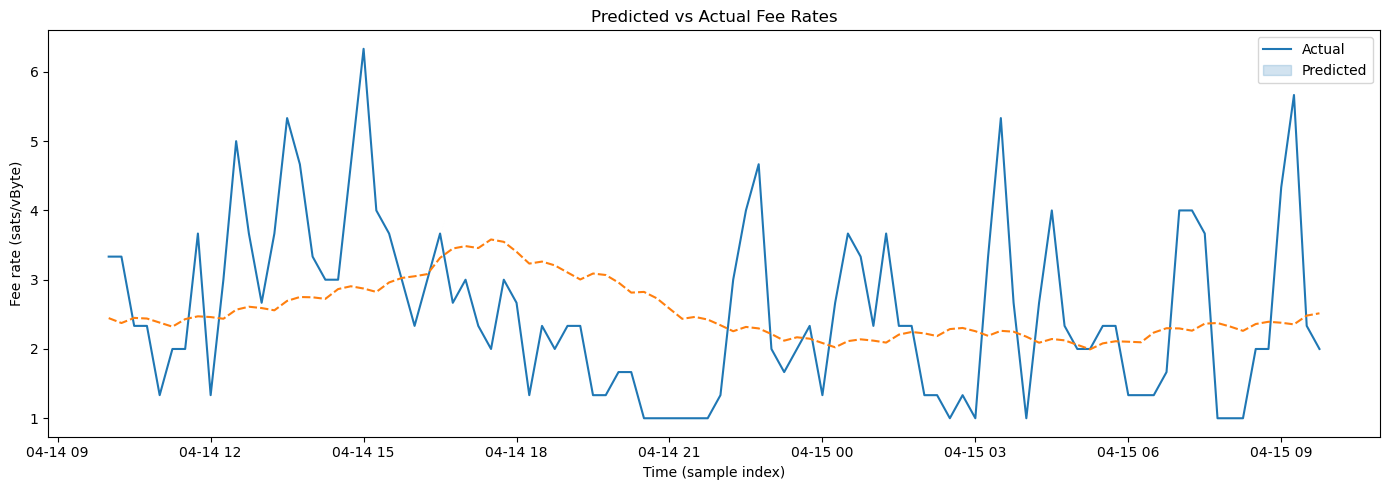

In [18]:
result_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=y_test.index)

plt.figure(figsize=(14, 5))
sns.lineplot(data=result_df)
plt.title('Predicted vs Actual Fee Rates')
plt.xlabel('Time (sample index)')
plt.ylabel('Fee rate (sats/vByte)')
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.show()